<a href="https://colab.research.google.com/github/Sakith-N/Statistical-Learning-e22252/blob/assignment--7/1_D_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.
$m_{k}^{-} = A\cdot m_{k-1} = a \cdot m_{k-1}$


$P_{k}^{-} = A P_{k-1} A^T + G \Sigma_p G^T = a \cdot P_{k-1} \cdot a + 1 \cdot q \cdot 1 = a^2P_{k-1}+q$

2.
The innovation variance scalar is $S_k = H P_{k}^{-} H^T + \Sigma_m = h^2P_{k}^{-}+r$.
The Kalman gain simplifies to:

$K_k = \frac{P_{k}^{-}h}{S_k} = \frac{P_{k}^{-}h}{h^2P_{k}^{-}+r}$

Substituting $K_k$ into the mean update equation:

$$m_{k} = m_{k}^{-}+\frac{P_{k}^{-}h}{S_{k}}(y_{k}^{obs}-h~m_{k}^{-})$$

Substituting $K_k$ into the covariance update equation:

$P_{k} = (1-K_{k}h)P_{k}^{-} = \left(1-\frac{P_{k}^{-}h^{2}}{S_{k}}\right)P_{k}^{-}$

3.
Based on prior information is $x_{k}^{-} \sim \mathcal{N}(m_{k}^{-}, P_{k}^{-})$. Given $y_{k}^{-} = hx_{k}^{-} + z_{k}$:

$\mathbb{E}[y_{k}^{-}|Y_{k-1}] = \mathbb{E}[hx_{k}^{-} + z_{k}] = h\mathbb{E}[x_{k}^{-}] + \mathbb{E}[z_k] = h m_{k}^{-} + 0 = hm_{k}^{-}$


$\text{Var}(y_{k}^{-}|Y_{k-1}) = \text{Var}(hx_{k}^{-} + z_{k}) = h^2\text{Var}(x_{k}^{-}) + \text{Var}(z_k) = h^2P_{k}^{-}+r$


Since it is a linear configuration of Gaussian variables, $p(y_{k}^{-}|Y_{k-1})=\mathcal{N}(h~m_{k}^{-},h^{2}P_{k}^{-}+r)$.

4.
$\mathbb{E}[hx_{k} + z_{k} | Y_k] = h\mathbb{E}[x_k | Y_k] + 0 = hm_k$

$\mathbb{E}[hx_{k} + z_{k} | Y_k] = h\mathbb{E}[x_k | Y_k] + 0 = hm_k$

Thus, the distribution becomes $\mathcal{N}(h~m_{k},h^{2}P_{k}+r)$.

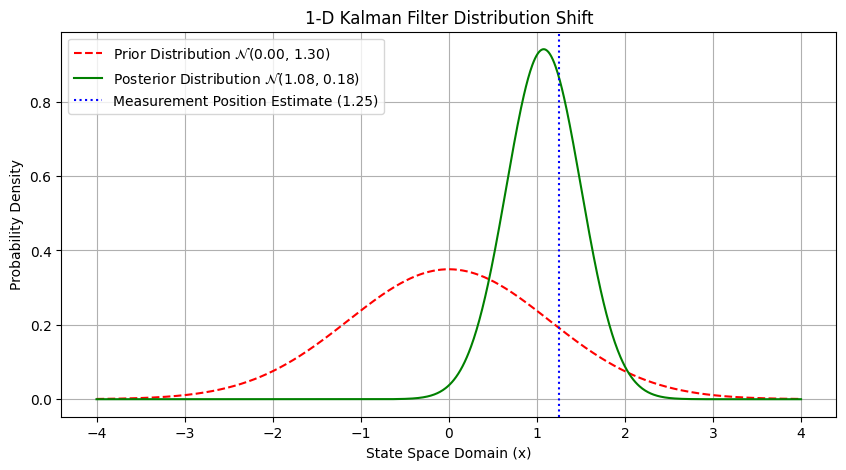

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

a, q, h, r = 0.95, 0.4, 1.2, 0.3
m0, P0 = 0.0, 1.0
y_obs = 1.5

m_minus = a * m0
P_minus = (a**2) * P0 + q
S = (h**2) * P_minus + r
K = (P_minus*h) / S
m_post = m_minus + K * (y_obs - h*m_minus)
P_post = (1 - K*h) * P_minus

x = np.linspace(-4, 4, 1000)
plt.figure(figsize=(10, 5))

plt.plot(x, norm.pdf(x, m_minus, np.sqrt(P_minus)), 'r--',
         label=f'Prior Distribution $\\mathcal{{N}}$({m_minus:.2f}, {P_minus:.2f})')

plt.plot(x, norm.pdf(x, m_post, np.sqrt(P_post)), 'g-',
         label=f'Posterior Distribution $\\mathcal{{N}}$({m_post:.2f}, {P_post:.2f})')

plt.axvline(x=y_obs/h, color='b', linestyle=':',
            label=f'Measurement Position Estimate ({y_obs/h:.2f})')

plt.title('1-D Kalman Filter Distribution Shift')
plt.xlabel('State Space Domain (x)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()